# Libraries and Function Defs

In [2]:
%%writefile part_a.py
import numpy as np
import pandas as pd
import sys

def load_test_train(traindata_filepath,testdata_filepath):
    train_data = pd.read_csv(traindata_filepath)
    test_data = pd.read_csv(testdata_filepath)
    return (train_data,test_data)

# Normalized Mean Absolute Error
def NMAE(y_pred,y_real):
    y_mean = np.mean(y_real)
    n = y_real.shape[0]
    numerator = 0
    denominator = 0
    for i in range(n):
        numerator+=abs(y_real[i,0]-y_pred[i,0])
        denominator+=abs(y_real[i,0]-y_mean)
    return numerator/denominator

# Normalized Mean Squared Error
def NMSE(y_pred,y_real):
    y_mean = np.mean(y_real)
    n = y_real.shape[0]
    numerator = 0
    denominator = 0
    for i in range(n):
        numerator+=(y_real[i,0]-y_pred[i,0])**2
        denominator+=(y_real[i,0]-y_mean)**2
    return numerator/denominator

def get_X_y(data,target_col=None):
    X = data.to_numpy()
    y = None
    if(target_col):
        X = data.drop(columns=[target_col]).to_numpy()
        y = data[target_col].to_numpy().reshape((-1,1))
    n,m = X.shape
    X = np.column_stack((np.ones(n), X))
    return (X,y)

def train(X,y):
    w = np.linalg.inv(X.T @ X) @ X.T @ y
    return w
def predict(X,w):
    return X @ w

Writing part_a.py


# For Testing On Collab

In [ ]:
/kaggle/input/datasets/souravkumarpatel/assignment1-heart-rate-linear-regression/e4_hr_train_downsampled.csv
/kaggle/input/datasets/souravkumarpatel/assignment1-heart-rate-linear-regression/e4_hr_test_downsampled.csv

In [5]:
base_filepath = "/kaggle/input/datasets/souravkumarpatel/assignment1-heart-rate-linear-regression/"
train_data,test_data = load_test_train(base_filepath+"e4_hr_train_downsampled.csv",base_filepath+"e4_hr_test_downsampled.csv")

In [62]:
train_data

,acc_x_s0_0,acc_x_s0_1,acc_x_s0_2,acc_x_s0_3,acc_x_s0_4,acc_x_s0_5,acc_x_s0_6,acc_x_s0_7,acc_x_s0_8,acc_x_s0_9,...,bvp_s9_59,bvp_s9_60,bvp_s9_61,bvp_s9_62,bvp_s9_63,eda_s9_0,eda_s9_1,eda_s9_2,eda_s9_3,hr
0,49,50,49,49,49,49,49,49,49,49,...,-62.71,-56.96,-51.76,-48.69,-48.09,0.000000,0.000000,0.000000,0.000000,71.90
1,34,34,38,28,22,45,51,61,64,64,...,-1.38,0.48,2.98,4.83,5.17,0.000000,0.000000,0.000000,0.000000,71.40
2,60,60,60,61,60,60,60,60,60,60,...,3.76,2.95,2.11,1.28,0.52,0.000000,0.000000,0.000000,0.000000,71.00
3,60,60,60,60,60,60,60,60,60,60,...,52.93,34.45,24.12,27.77,47.45,0.000000,0.000000,0.000000,0.000000,69.88
4,57,57,57,57,57,56,57,57,57,57,...,3.97,13.76,22.14,29.66,36.55,0.000000,0.000000,0.000000,0.000000,69.73
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
158981,60,63,64,62,60,65,61,64,68,66,...,-174.50,-180.95,-188.68,-194.87,-195.87,0.592011,0.590729,0.593292,0.592011,96.42
158982,53,51,46,32,59,62,60,66,53,66,...,-68.77,-42.26,-15.34,11.77,38.77,0.593292,0.592011,0.592011,0.590729,95.92
158983,53,44,42,39,38,35,45,53,55,49,...,54.54,49.21,38.85,22.08,-1.13,0.592011,0.592011,0.592011,0.593292,95.62
158984,-3,15,0,-3,2,18,4,-7,10,6,...,-630.56,-623.74,-597.36,-553.82,-498.82,0.592011,0.593292,0.592011,0.592011,95.08


In [61]:
test_data

,acc_x_s0_0,acc_x_s0_1,acc_x_s0_2,acc_x_s0_3,acc_x_s0_4,acc_x_s0_5,acc_x_s0_6,acc_x_s0_7,acc_x_s0_8,acc_x_s0_9,...,bvp_s9_59,bvp_s9_60,bvp_s9_61,bvp_s9_62,bvp_s9_63,eda_s9_0,eda_s9_1,eda_s9_2,eda_s9_3,hr
0,5,5,5,5,5,5,5,5,5,3,...,-7.49,-7.96,-8.98,-10.34,-11.73,0.219121,0.219121,0.219121,0.217839,77.80
1,11,19,17,18,19,17,14,12,11,3,...,-9.94,-10.45,-9.76,-7.96,-5.26,0.217839,0.216558,0.217839,0.216558,75.23
2,9,9,9,8,8,8,8,9,9,9,...,-8.09,-10.78,-12.75,-14.05,-15.15,0.220402,0.220402,0.219121,0.220402,71.31
3,10,8,8,10,10,9,10,12,12,8,...,-395.79,-429.27,-440.82,-427.59,-391.31,0.217839,0.217839,0.217839,0.216558,71.00
4,16,16,16,15,15,15,15,14,14,15,...,-15.08,-12.25,-9.52,-6.14,-1.63,0.216558,0.217839,0.217839,0.217839,71.82
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
52995,-8,-8,-1,-2,0,3,-1,-5,-12,-3,...,80.21,58.50,41.23,30.54,25.33,4.353073,4.353073,4.350510,4.351791,124.97
52996,21,21,22,19,18,22,24,29,25,21,...,-18.44,-19.14,-17.28,-12.96,-6.58,4.351791,4.350510,4.353073,4.353073,125.03
52997,14,17,19,21,23,28,27,26,23,23,...,6.88,-5.42,-21.58,-39.57,-56.40,4.350510,4.351791,4.351791,4.351791,125.97
52998,28,24,20,27,31,37,30,34,37,34,...,-51.35,-41.92,-27.34,-7.35,15.38,4.351791,4.353073,4.351791,4.351791,126.97


In [6]:
X_train,y_train = get_X_y(train_data,"hr")
X_test,y_test = get_X_y(test_data,"hr")

In [5]:
X_train

array([[ 1.      , 49.      , 50.      , ...,  0.      ,  0.      ,
         0.      ],
       [ 1.      , 34.      , 34.      , ...,  0.      ,  0.      ,
         0.      ],
       [ 1.      , 60.      , 60.      , ...,  0.      ,  0.      ,
         0.      ],
       ...,
       [ 1.      , 53.      , 44.      , ...,  0.592011,  0.592011,
         0.593292],
       [ 1.      , -3.      , 15.      , ...,  0.593292,  0.592011,
         0.592011],
       [ 1.      , 34.      , 27.      , ...,  0.592011,  0.592011,
         0.592011]])

In [7]:
w = train(X_train,y_train)

In [9]:
y_prediction_train = predict(X_train,w)
y_prediction_test = predict(X_test,w)

In [ ]:
y_prediction_train

In [10]:
print("Train NMAE : ",NMAE(y_prediction_train,y_train))
print("Train NMSE : ",NMSE(y_prediction_train,y_train))
print("Test NMAE : ",NMAE(y_prediction_test,y_test))
print("Test NMSE : ",NMSE(y_prediction_test,y_test))

Train NMAE :  0.9433361712306896
Train NMSE :  0.8958195208077645
Test NMAE :  0.9790757959604021
Test NMSE :  0.9890818653768296


# Main Block for file

In [3]:
%%writefile -a part_a.py
def main(train_path, test_path, pred_path, weights_path):
    train_data,test_data = load_test_train(train_path,test_path)

    X_train,y_train = get_X_y(train_data,"hr")
    X_test,_ = get_X_y(test_data,"hr")

    w = train(X_train,y_train)
    y_pred_test = predict(X_test,w)

    np.savetxt(pred_path, y_pred_test.flatten(), fmt="%.16f")
    np.savetxt(weights_path, w.flatten(), fmt="%.16f")

if __name__ == "__main__":
    train_path, test_path, pred_path, weights_path = sys.argv[1:5]
    main(train_path, test_path, pred_path, weights_path)

Appending to part_a.py


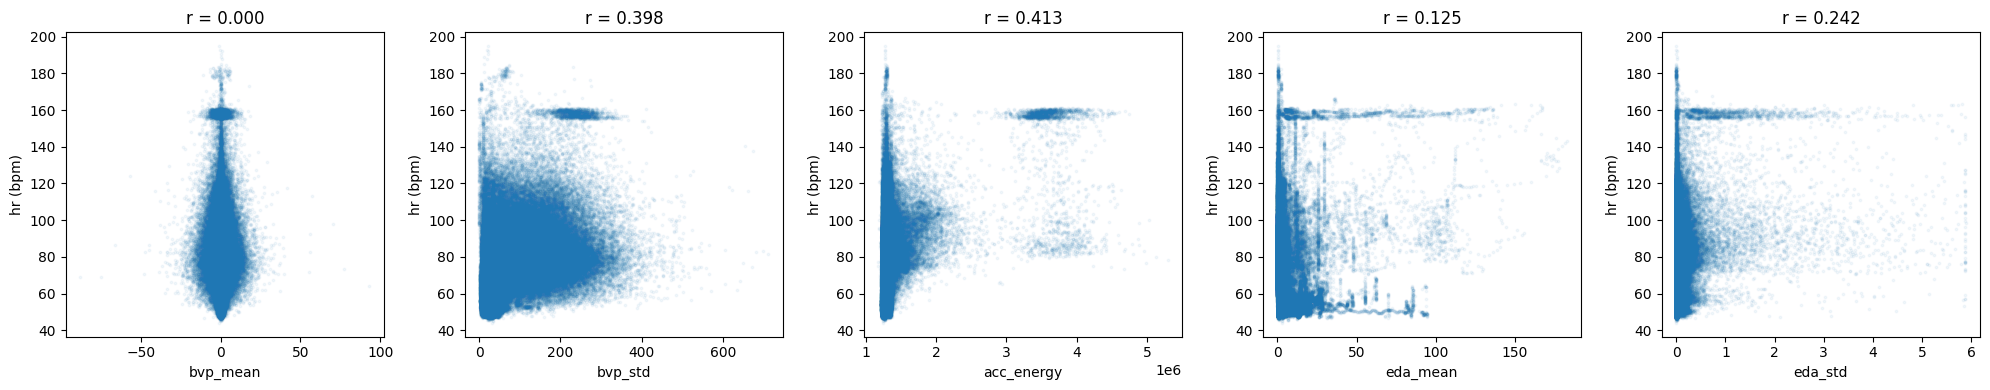

In [57]:
# import matplotlib.pyplot as plt

# bvp_cols = [c for c in train_data.columns if c.startswith("bvp")]
# accx_cols = [c for c in train_data.columns if c.startswith("acc_x")]
# accy_cols = [c for c in train_data.columns if c.startswith("acc_y")]
# accz_cols = [c for c in train_data.columns if c.startswith("acc_z")]
# eda_cols = [c for c in train_data.columns if c.startswith("eda")]

# df = train_data.copy()
# df["bvp_mean"]  = df[bvp_cols].mean(axis=1)
# df["bvp_std"]   = df[bvp_cols].std(axis=1)
# df["acc_energy"] = (df[accx_cols]**2).sum(axis=1) + (df[accy_cols]**2).sum(axis=1) + (df[accz_cols]**2).sum(axis=1)
# df["eda_mean"]  = df[eda_cols].mean(axis=1)
# df["eda_std"]   = df[eda_cols].std(axis=1)

# summary_feats = ["bvp_mean", "bvp_std", "acc_energy", "eda_mean", "eda_std"]

# fig, axes = plt.subplots(1, len(summary_feats), figsize=(4*len(summary_feats), 4))
# for ax, feat in zip(axes, summary_feats):
#     ax.scatter(df[feat], df["hr"], alpha=0.05, s=3)
#     ax.set_xlabel(feat)
#     ax.set_ylabel("hr (bpm)")
#     r = df[feat].corr(df["hr"])
#     ax.set_title(f"r = {r:.3f}")
# plt.tight_layout()
# plt.show()

In [26]:
!python3 part_a.py /kaggle/input/datasets/souravkumarpatel/assignment1-heart-rate-linear-regression/e4_hr_train_downsampled.csv /kaggle/input/datasets/souravkumarpatel/assignment1-heart-rate-linear-regression/e4_hr_test_downsampled.csv skp_pred.txt skp_weights.txt